# **Packages**

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **Data Import**

In [39]:
# Import CSV
df = pd.read_csv("../data/car_price_dataset.csv")

In [40]:
# Checking first 10 rows
df.head(10)

,Car_ID,Brand,Model_Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Horsepower,Price
0,1,Ford,2023,1.2,Hybrid,Manual,180635,4,3,82,34309.25
1,2,Hyundai,2018,3.2,Electric,Manual,35628,2,4,259,55153.60
2,3,BMW,2008,2.2,Diesel,Manual,74672,3,2,333,41894.40
3,4,Hyundai,2017,2.2,Petrol,Automatic,51246,4,4,381,54046.70
4,5,Hyundai,2012,2.4,Electric,Manual,147233,3,4,290,38010.35
5,6,Honda,2023,3.5,Petrol,Automatic,94110,2,4,173,54182.50
6,7,BMW,2016,2.3,Petrol,Manual,7810,2,3,267,52140.50
7,8,BMW,2022,3.9,Petrol,Automatic,195932,4,1,369,61707.40
8,9,BMW,2010,2.6,Electric,Manual,76688,3,1,238,44992.60
9,10,Hyundai,2022,1.3,Electric,Manual,70548,4,4,218,40924.60


Based on the results of `df.head()`, we can see:

1. There are 11 variable columns, with the `Price` column serving as the target variable

2. There are 3 columns of data of type `object`, 2 of type `float`, and the rest are `integer`

3. To better represent the data, the `Model_Year` column will be simplified to `Age`

# **Data Checking**

Data checking is performed to understand the initial state of the dataset so that data cleaning efforts are targeted effectively. The steps involved include identifying patterns of errors in the data, such as missing values and duplicates, and verifying the data structure and format. 

In [41]:
# Data info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car_ID        2000 non-null   int64  
 1   Brand         2000 non-null   object 
 2   Model_Year    2000 non-null   int64  
 3   Engine_Size   2000 non-null   float64
 4   Fuel_Type     2000 non-null   object 
 5   Transmission  2000 non-null   object 
 6   Mileage       2000 non-null   int64  
 7   Doors         2000 non-null   int64  
 8   Owner_Count   2000 non-null   int64  
 9   Horsepower    2000 non-null   int64  
 10  Price         2000 non-null   float64
dtypes: float64(2), int64(6), object(3)
memory usage: 172.0+ KB


Based on the results from `df.info()`, it can be seen that there are no missing values in any column and that all columns have the correct data types. To further verify this, a check for duplicate data was then performed.

In [42]:
# Duplicated rows
df.duplicated().sum()

np.int64(0)

In [43]:
# Duplicated in Car_ID
df["Car_ID"].duplicated().sum()

np.int64(0)

Based on the results of the duplicate data check, no duplicate records were found, either across all columns or based on the `Car_ID`, which is supposed to be unique.

In [44]:
# Age feature creation
df['Age'] = 2026 - df['Model_Year']

In [45]:
# Drop Model_Year as we have Age
df.drop('Model_Year', axis=1, inplace=True)

To simplify the data representation, the `Model_Year` column has been renamed to `Age`, with the calculation starting from the year 2026.

In [46]:
# Final data info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car_ID        2000 non-null   int64  
 1   Brand         2000 non-null   object 
 2   Engine_Size   2000 non-null   float64
 3   Fuel_Type     2000 non-null   object 
 4   Transmission  2000 non-null   object 
 5   Mileage       2000 non-null   int64  
 6   Doors         2000 non-null   int64  
 7   Owner_Count   2000 non-null   int64  
 8   Horsepower    2000 non-null   int64  
 9   Price         2000 non-null   float64
 10  Age           2000 non-null   int64  
dtypes: float64(2), int64(6), object(3)
memory usage: 172.0+ KB


# **Exploratory Data Analysis**

EDA (Exploratory Data Analysis) is conducted as an in-depth process to gain a visual and statistical understanding of the data before moving on to the modeling phase. The EDA process typically involves identifying hidden patterns in the data (such as correlations or clusters), validating assumptions, directing the analysis toward influential variables, and communicating findings visually through graphs.

## **Statistics Descriptive**

Descriptive statistics are used to summarize large datasets into concise, easy-to-understand information, particularly for numerical variables and target variables such as `Price`.

In [47]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Car_ID,2000.0,NaN,NaN,NaN,1000.5,577.494589,1.0,500.75,1000.5,1500.25,2000.0
Brand,2000,6,Toyota,352,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Engine_Size,2000.0,NaN,NaN,NaN,2.96755,1.146926,1.0,2.0,2.9,4.0,5.0
Fuel_Type,2000,4,Diesel,537,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transmission,2000,2,Automatic,1018,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Mileage,2000.0,NaN,NaN,NaN,100736.9565,56002.915221,5036.0,52365.5,100590.5,148024.5,199904.0
Doors,2000.0,NaN,NaN,NaN,2.988,0.818041,2.0,2.0,3.0,4.0,4.0
Owner_Count,2000.0,NaN,NaN,NaN,2.5325,1.125423,1.0,2.0,3.0,4.0,4.0
Horsepower,2000.0,NaN,NaN,NaN,235.7095,95.59811,70.0,154.0,236.0,319.0,399.0
Price,2000.0,NaN,NaN,NaN,46169.507675,9211.685713,18911.55,39764.0,46112.35,52471.3875,72267.8


## **Price Analysis**

In [48]:
# Price describe
df["Price"].describe().T

count     2000.000000
mean     46169.507675
std       9211.685713
min      18911.550000
25%      39764.000000
50%      46112.350000
75%      52471.387500
max      72267.800000
Name: Price, dtype: float64

Based on `df.describe()` for the `Price` variable, we can conclude that:

1. The mean price of cars in the dataset is $46,169.51, with a median of $46,112.45. These two values, which differ only slightly, indicate that the `Price` distribution is symmetric.

2. The standard deviation of $9,211.69 is smaller than the mean, indicating that car prices tend to cluster around the mean.

To investigate further, the distribution of `Price` was visualized using a histogram and a box plot.

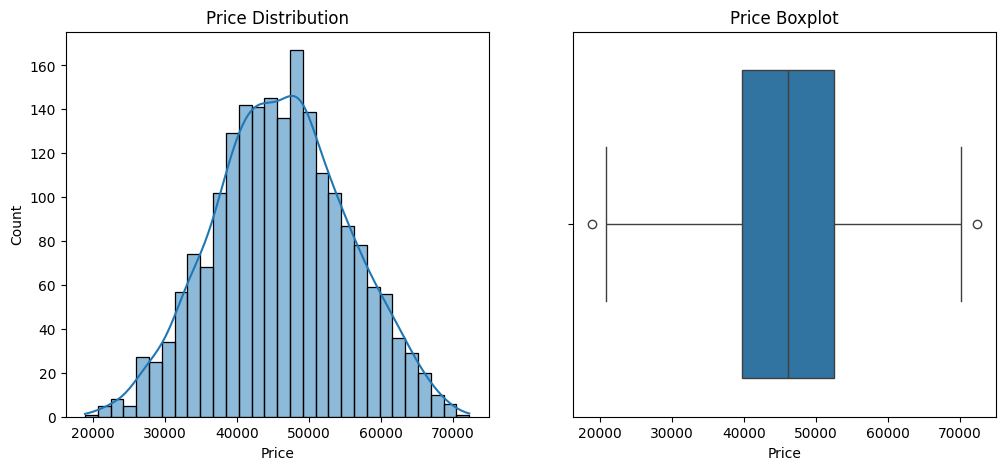

In [36]:
# Price distribution with histogram and boxplot
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df['Price'], bins=30, kde=True)
plt.title('Price Distribution')
plt.subplot(1,2,2)
sns.boxplot(x=df['Price'])
plt.title('Price Boxplot')
plt.show()

Based on these visualizations, we can see that:

1. The histogram shows a symmetrical (bell-shaped) distribution of `Price`, with car prices clustering around $40,000 to $55,000.

2. The boxplot shows a symmetrical shape, indicating that car prices tend to cluster around $40,000 to $55,000.

3. The boxplot also shows two outliers located not far from the "legs" of the boxplot. These outlier figures likely indicate prices influenced by factors such as mileage or vehicle specifications. 

In [49]:
# Skewness Check
df['Price'].skew()

np.float64(0.018929463908141805)

## **Correlation**

Correlation analysis is performed to measure the strength and relationship between two or more numerical variables. This step is also conducted to check for multicollinearity and detect anomalies among the numerical variables. Since `Car_ID` does not logically represent a relationship between variables—particularly with respect to `Price` (serving only as a unique identifier)—the `Car_ID` column is removed.

In [50]:
# Correlation for Numeric Column
matrix = df.corr(numeric_only=True).drop('Car_ID', axis=0).drop('Car_ID', axis=1)
matrix

,Engine_Size,Mileage,Doors,Owner_Count,Horsepower,Price,Age
Engine_Size,1.000000,0.015690,0.007902,0.002116,0.001128,0.614301,0.002629
Mileage,0.015690,1.000000,0.066935,-0.079931,0.024313,-0.266514,-0.021496
Doors,0.007902,0.066935,1.000000,0.011835,0.013056,-0.012256,0.000654
Owner_Count,0.002116,-0.079931,0.011835,1.000000,0.008269,-0.082610,-0.025856
Horsepower,0.001128,0.024313,0.013056,0.008269,1.000000,0.514551,-0.003596
Price,0.614301,-0.266514,-0.012256,-0.082610,0.514551,1.000000,-0.468666
Age,0.002629,-0.021496,0.000654,-0.025856,-0.003596,-0.468666,1.000000


For a cleaner visual representation, the output of `df.corr()` is visualized using a heatmap with the coolwarm palette (the bluer or redder the color, the stronger the correlation).

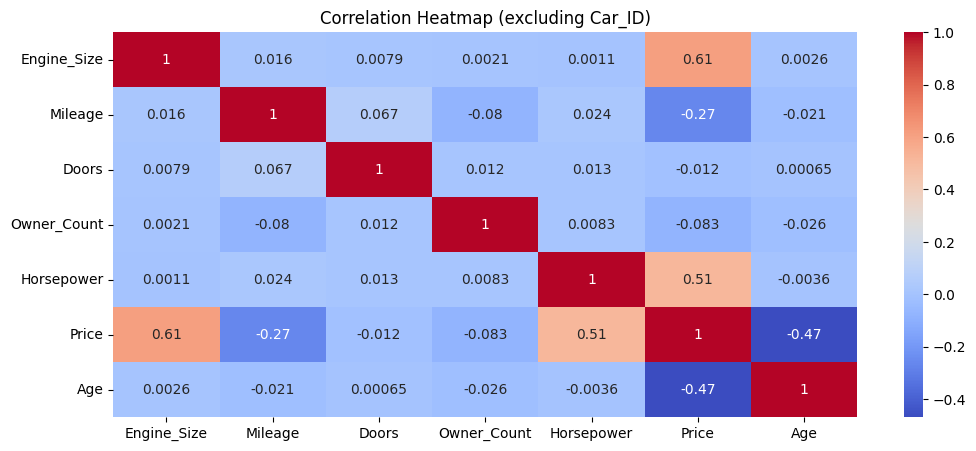

In [51]:
# Heatmap Correlation
plt.figure(figsize=(12,5))
sns.heatmap(matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap (excluding Car_ID)')
plt.show()

Based on the heatmap visualization, it can be concluded that:

1. The variables that have at least a fairly strong relationship with `Price` are `Engine_Size` (0.61), `Horsepower` (0.51), and `Age` (-0.47).

2. The larger the engine size and the higher the horsepower, the higher the car’s price. Meanwhile, the newer the car, the higher its price.

3. The correlations with variables other than `Price` are very small, suggesting that multicollinearity is not present.

To visualize correlations that focus more specifically on `Price`, a separate heatmap was created for numerical variables directly correlated with the `Price` variable, sorted from those with the strongest positive correlation to those with the strongest negative correlation. 

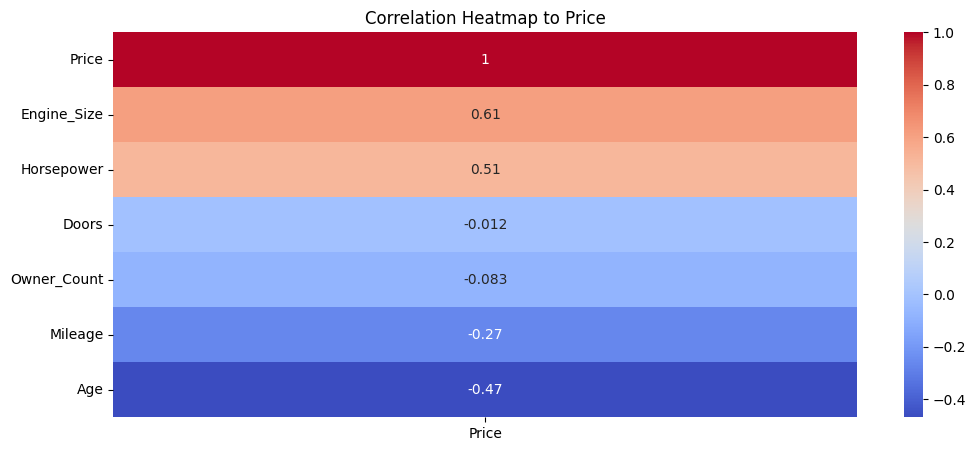

In [53]:
# Correlation Heatmap to Price, ascending order
plt.figure(figsize=(12,5))
sns.heatmap(matrix['Price'].to_frame().sort_values('Price', ascending=False), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap to Price')
plt.show()

From this visualization, we can see that the number of doors on a car and the number of previous owners have a very weak negative correlation with the car’s price.

## **Categorical Analysis**

Since correlations with `Price` can only be performed on numerical variables, this section aims to examine the distribution of `Price` according to categorical variables such as `Brand`, `Fuel_Type`, and `Transmission`, as well as to examine the distribution of the number of cars according to these variables.

### Brand

The first step is to examine the distribution of the number of cars in the dataset by brand using `countplot`.

Brand
Toyota     352
Hyundai    337
Tesla      330
Honda      329
Ford       326
BMW        326
Name: count, dtype: int64

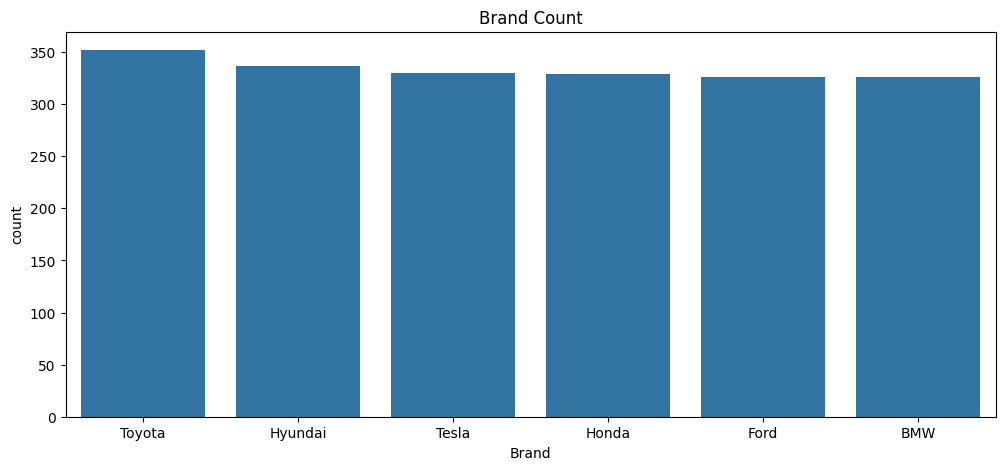

In [15]:
# Plot for Brand Count
plt.figure(figsize=(12,5))
sns.countplot(x='Brand', data=df, order=df['Brand'].value_counts().index)
plt.title('Brand Count')

display(df['Brand'].value_counts())
plt.show()

Based on the `countplot` visualization from `Brand`, the distribution of the number of cars shows nearly equal numbers across each brand, with Toyota being the most common brand in this dataset.

,Brand,Price
2,Honda,46584.091945
5,Toyota,46341.708523
0,BMW,46206.121166
1,Ford,46135.082975
4,Tesla,46123.820758
3,Hyundai,45627.520178


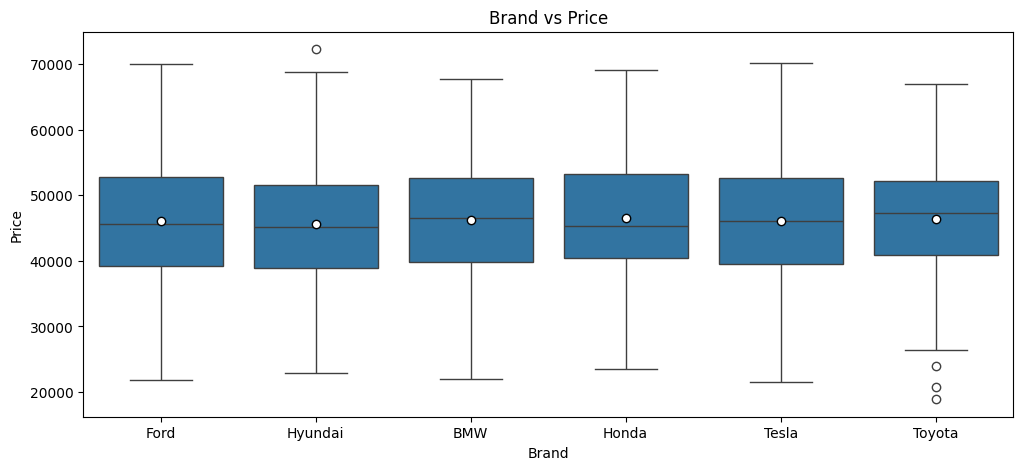

In [16]:
# Brand vs Price df and boxplot
brand_price = df.groupby('Brand')['Price'].mean().reset_index()
plt.figure(figsize=(12,5))
sns.boxplot(x='Brand', y='Price', data=df, 
            showmeans=True, meanprops={"marker":"o",
                       "markerfacecolor":"white",
                       "markeredgecolor":"black"})
plt.title('Brand vs Price')

display(brand_price.sort_values('Price', ascending=False))
plt.show()

Based on the boxplot visualization, it can be concluded that:

1. Almost all brands have very similar average prices, which are in the range of $45,000 - $46,000.

2. All brands have nearly uniform box widths, which means their price consistency is similar to one another.

3. Tesla and Ford have a very wide price range, indicating that they sell cars ranging from the lower price category to the luxury class.

4. On the other hand, Toyota has a more "compact" price range at the lower end, but has a few prices that are significantly lower (outliers).

5. When considered in relation to `Price`, the `Brand` variable shows a very low correlation, as evidenced by the interquartile ranges of each brand being at nearly the same level.

### Fuel Type

The first step is to examine the distribution of the number of cars in the dataset by fuel type using `countplot`.

Fuel_Type
Diesel      537
Petrol      511
Electric    484
Hybrid      468
Name: count, dtype: int64

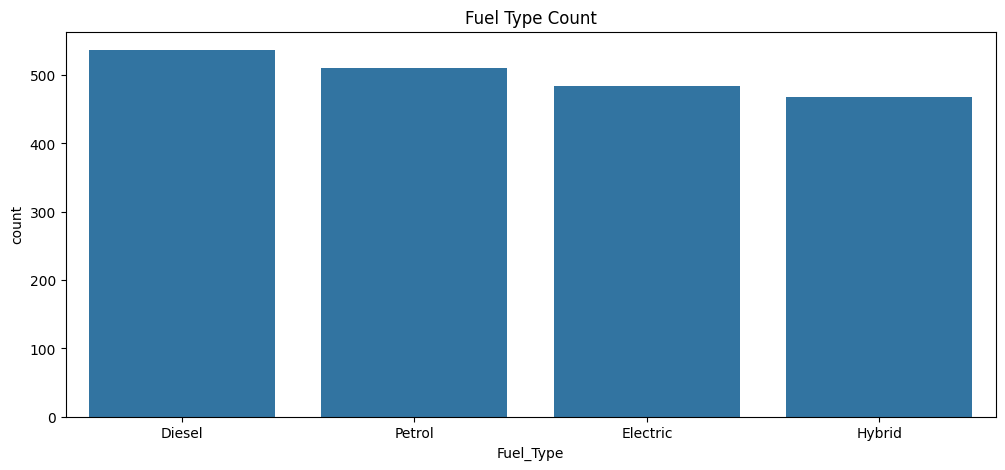

In [17]:
# Plot for Fuel_Type Count
plt.figure(figsize=(12,5))
sns.countplot(x='Fuel_Type', data=df, order=df['Fuel_Type'].value_counts().index)
plt.title('Fuel Type Count')

display(df['Fuel_Type'].value_counts())
plt.show()

Based on the `countplot` visualization, diesel-powered vehicles are the most numerous in this dataset (537 cars).

,Fuel_Type,Price
3,Petrol,47132.047847
2,Hybrid,46004.613675
0,Diesel,45810.225326
1,Electric,45711.340289


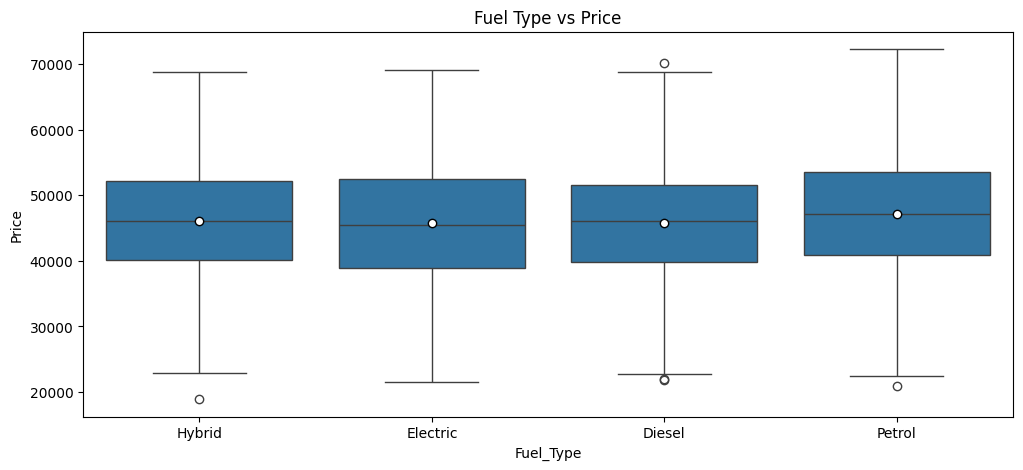

In [18]:
# Fuel Type vs Price df and boxplot
fuel_price = df.groupby('Fuel_Type')['Price'].mean().reset_index()
plt.figure(figsize=(12,5))
sns.boxplot(x='Fuel_Type', y='Price', data=df, showmeans=True,
            meanprops={"marker":"o",
                       "markerfacecolor":"white",
                       "markeredgecolor":"black"})
plt.title('Fuel Type vs Price')

display(fuel_price.sort_values('Price', ascending=False))
plt.show()

Based on the boxplot visualization, it can be concluded that:

1. The four fuel types have relatively similar average prices, ranging around $45,000 - $47,000.

2. Each fuel type has a very similar distribution, ranging from a low of nearly $20,000 to a high of $70,000 or more.

3. The presence of outliers does not alter the overall picture that the majority of the data clusters in the same area.

4. Like `Brand`, `Fuel_Type` is assumed to have a very low correlation based on the identical interquartile range for each fuel type.

### Transmissions

The first step is to examine the distribution of the number of cars in the dataset by transmissions using `countplot`.

Transmission
Automatic    1018
Manual        982
Name: count, dtype: int64

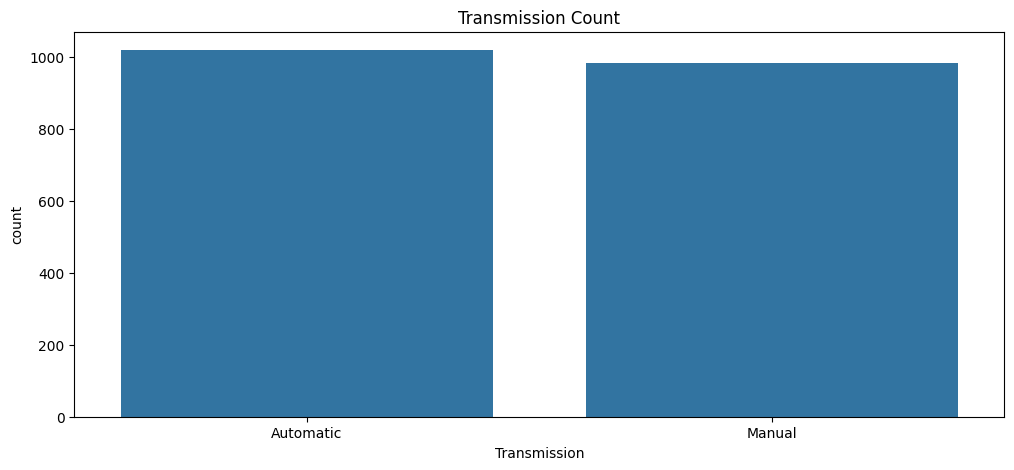

In [19]:
# Plot for Transmission Count
plt.figure(figsize=(12,5))
sns.countplot(x='Transmission', data=df, order=df['Transmission'].value_counts().index)
plt.title('Transmission Count')

display(df['Transmission'].value_counts())
plt.show()

Based on the `countplot` visualization, there are only two types of transmissions in this dataset, with automatic transmissions being the most common, although the number is not significantly different from that of manual transmissions.

,Transmission,Price
0,Automatic,46265.151031
1,Manual,46070.358045


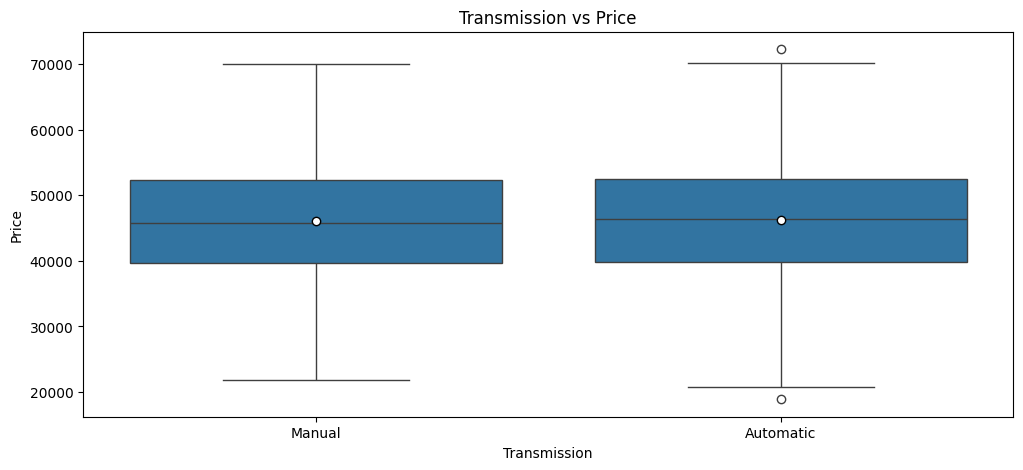

In [20]:
# Transmission vs Price df and boxplot
trans_price = df.groupby('Transmission')['Price'].mean().reset_index()
plt.figure(figsize=(12,5))
sns.boxplot(x='Transmission', y='Price', data=df, showmeans=True,
            meanprops={"marker":"o",
                       "markerfacecolor":"white",
                       "markeredgecolor":"black"})
plt.title('Transmission vs Price')

display(trans_price.sort_values('Price', ascending=False))
plt.show()

Based on the boxplot visualization, we can conclude that:

1. Both are on nearly parallel lines (around $46,000). This means that, on average, the prices of manual and automatic transmission cars in this dataset do not differ significantly.

2. The width of the blue boxes for both is exactly the same, ranging from approximately $40,000 to $52,000.

3. Both have nearly identical price ranges, from approximately $20,000 to $70,000.

4. Like the other two categorical variables, `Transmissions` is assumed to have a very low correlation with `Price` based on the identical interquartile ranges of each transmission type.

### Engine Size vs Price

Since the correlation between `Engine_Size` and `Price` is fairly strong (0.61), a scatter plot was created using `regplot` to visualize the trend of the relationship and see how closely the data follows a straight line (linear).

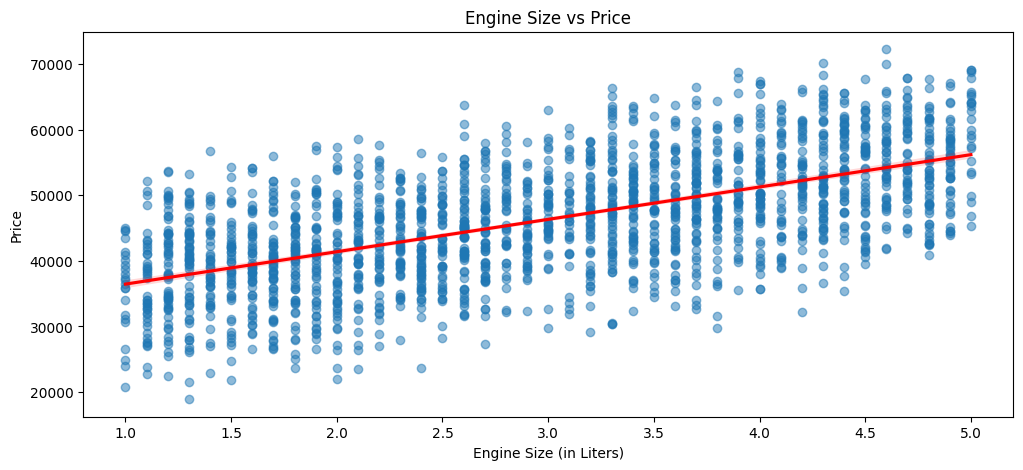

In [52]:
# Engine Size vs Price regression plot
plt.figure(figsize=(12,5))
sns.regplot(x='Engine_Size', y='Price', data=df, 
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Engine Size vs Price')
plt.xlabel('Engine Size (in Liters)')
plt.ylabel('Price')
plt.show()

Based on the `regplot` visualization, we can see that:

1. The red line (regression line) sloping upward from the bottom left to the top right confirms a positive correlation; as engine size increases, the price of the car tends to increase as well.

2. Although there is some scatter (noise), the data points are not randomly distributed across the entire graph; they form an elongated pattern.

3. Larger engines provide a higher "floor" for the price. It is rare to find a car with a 5 L engine capacity priced below $30,000, while cars with a 1 L engine capacity are very common in that price range.

4. A correlation of 0.61 indicates that while engine size has a significant influence, there are still other factors that determine the final price.

### Horsepower vs Price

The correlation between `Horsepower` and `Price` indicates a fairly strong relationship (0.51). A scatter plot was created using `regplot` to visually illustrate the trend of the relationship and assess how closely the data follows a straight line (linear).

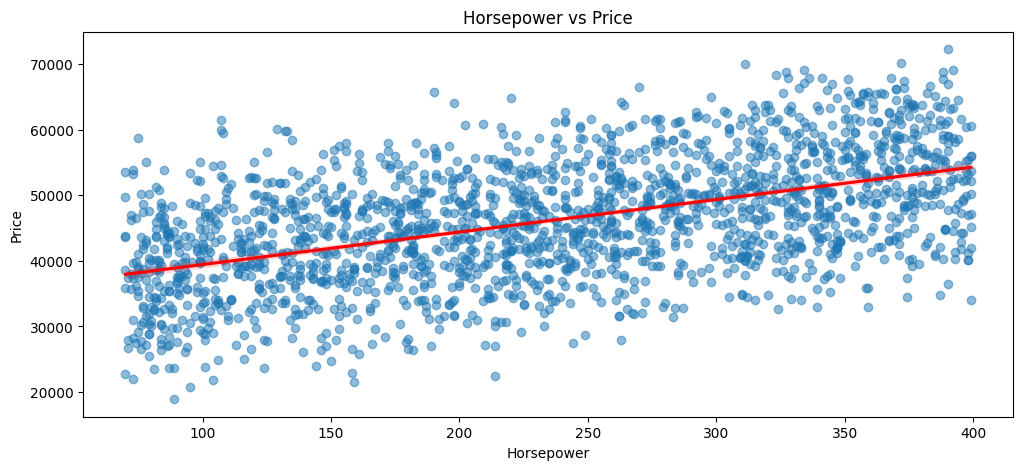

In [22]:
# Horsepower vs Price regression plot
plt.figure(figsize=(12,5))
sns.regplot(x='Horsepower', y='Price', data=df, 
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Horsepower vs Price')
plt.show()

Based on the `regplot` visualization, we can conclude that:

1. Just like `Engine_Size`, `Horsepower` also has a positive correlation with price. The red regression line shows a clear upward trend; car prices rise as horsepower increases.

2. Unlike `Engine_Size`, whose data appears discontinuous per unit, the `Horsepower` data is more continuous (spreading evenly from 70 to 400 HP).

3. Although the trend is upward, the vertical spread of the blue data points is very wide; at 100 HP, there are cars priced at $20,000, but others reach as high as $60,000.

### Age vs Price

Unlike `Engine_Size` and `Horsepower`, `Age` has a fairly strong negative correlation with `Price` (-0.47). A scatter plot was created using `regplot` to visually illustrate the trend of the relationship and assess how closely the data follows a straight line (linear).

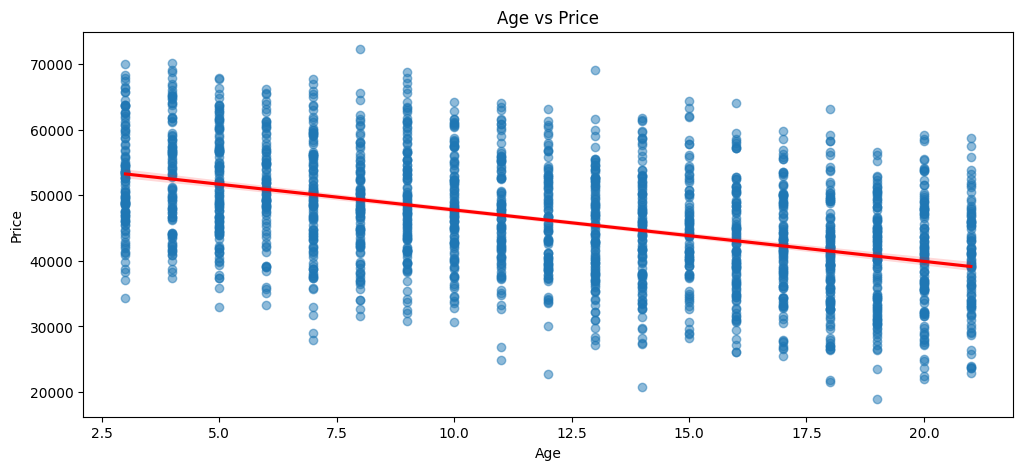

In [23]:
# Age vs Price regression plot
plt.figure(figsize=(12,5))
sns.regplot(x='Age', y='Price', data=df, 
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Age vs Price')
plt.show()

Based on the `regplot` visualization, we can conclude that:

1. Unlike `Engine_Size` or `Horsepower`, whose lines rise, the red line here slopes downward from left to right; as a car gets older, its price tends to decrease.

2. A car’s age has a fairly strong influence on its price, but it is not the only determining factor.

3. Although the regression line slopes downward, each “age” column has a long vertical spread of data points; this indicates that even at the same age, there are still significant price differences.

# **Data Export**

Export clean data for use in regression scripts by removing `Car_ID`

In [24]:
# Drop Car_ID as it is not useful for modeling
df.drop('Car_ID', axis=1, inplace=True)

In [25]:
# Export cleaned data to CSV
df.to_csv("../data/car_price_dataset_cleaned.csv", index=False)

# **Conclusion**

The exploratory data analysis shows that the dataset is clean, well-structured, and suitable for regression modeling. The target variable is reasonably well-distributed, with minimal outliers and no significant data quality issues.

Several numerical features, such as engine size, horsepower, and age, exhibit noticeable relationships with price, indicating their potential as strong predictors.

On the other hand, categorical features do not show clear separation in price distributions, as observed from relatively similar boxplot patterns across categories. This suggests that their individual contribution to price variation may be limited, although they are still included for completeness and potential interaction effects.

Overall, the data shows structured patterns with a tendency toward linear relationships, providing a strong foundation for applying regression models in the next stage.